## Part 4 – Sensory Drivers of Liking ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('../data/snack_consumer_sensory_dataset.csv')
data.head()

,respondent_id,market,age,gender,product,overall_liking,sweetness,crunchiness,oiliness,aftertaste
0,10001,UK,34,Female,A_CrunchyClassic,7,3.0,6.1,5.5,3.9
1,10001,UK,34,Female,B_SweetSpicy,8,7.1,7.1,3.9,5.9
2,10001,UK,34,Female,C_LightBaked,4,3.1,6.5,4.6,2.9
3,10001,UK,34,Female,D_RichCheesy,3,5.2,4.1,6.3,6.0
4,10002,US,50,Female,A_CrunchyClassic,7,2.7,7.9,5.0,2.1


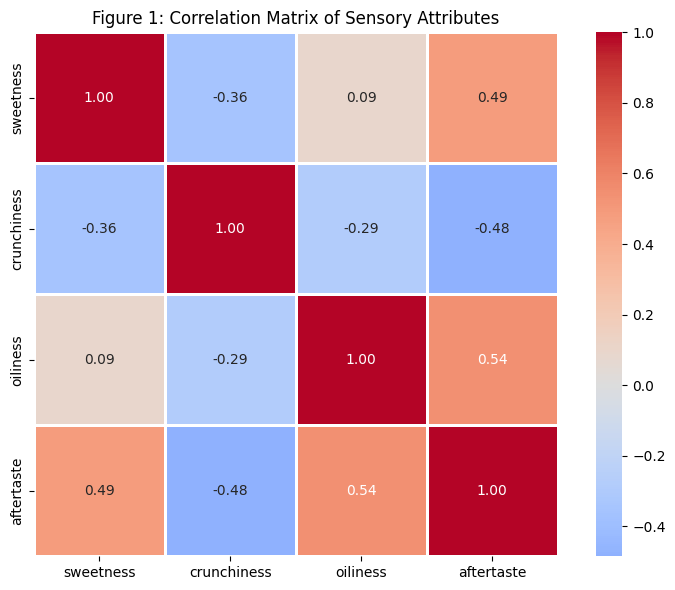

In [ ]:
sensory_vars = ['sweetness', 'crunchiness', 'oiliness', 'aftertaste']

# Correlation matrix
cor_matrix = data[sensory_vars].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Figure 1: Correlation Matrix of Sensory Attributes')
plt.tight_layout()
plt.show()

In [9]:
# CELL 3: Calculate Variance Inflation Factor (VIF)
# Add constant for VIF calculation
X = add_constant(data[sensory_vars])
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("VARIANCE INFLATION FACTORS:")
print(vif_data)
print("\n")

VARIANCE INFLATION FACTORS:
      Variable        VIF
0        const  86.993767
1    sweetness   1.426623
2  crunchiness   1.348308
3     oiliness   1.492169
4   aftertaste   2.100557




In [16]:
# CELL 4: Multiple Linear Regression (Corrected)
model = ols('overall_liking ~ sweetness + crunchiness + oiliness + aftertaste', data=data).fit()

print("MULTIPLE LINEAR REGRESSION RESULTS:")
print("="*50)
print(model.summary().tables[1])  # Coefficients table
print("\n")
print(f"R-squared: {model.rsquared:.3f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.3f}")
print(f"F-statistic: {model.fvalue:.3f}, p-value: {model.f_pvalue:.4f}")

# Create coefficients dataframe - EXCLUDING INTERCEPT for driver analysis
coef_df = pd.DataFrame({
    'Attribute': model.params.index,
    'Coefficient': model.params.values,
    'P-value': model.pvalues.values,
    'Significant': model.pvalues.values < 0.05
})

# Separate intercept and attributes
intercept_value = coef_df[coef_df['Attribute'] == 'Intercept']['Coefficient'].values[0]
attribute_coefs = coef_df[coef_df['Attribute'] != 'Intercept'].copy()

print("\nCOEFFICIENTS DETAILED:")
print(attribute_coefs)

MULTIPLE LINEAR REGRESSION RESULTS:
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       4.5355      0.327     13.875      0.000       3.894       5.177
sweetness       0.5514      0.026     21.068      0.000       0.500       0.603
crunchiness     0.3945      0.032     12.315      0.000       0.332       0.457
oiliness       -0.3149      0.031    -10.054      0.000      -0.376      -0.253
aftertaste     -0.4442      0.037    -11.920      0.000      -0.517      -0.371


R-squared: 0.561
Adjusted R-squared: 0.559
F-statistic: 279.383, p-value: 0.0000

COEFFICIENTS DETAILED:
     Attribute  Coefficient       P-value  Significant
1    sweetness     0.551355  5.092274e-80         True
2  crunchiness     0.394511  2.958585e-32         True
3     oiliness    -0.314870  1.409449e-22         True
4   aftertaste    -0.444178  1.842314e-30         True
